<a href="https://colab.research.google.com/github/darklsor56/CS105-Team11-SP26/blob/main/CS105_mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Team members:
* Andrew Maciborski
* Vincent Chau
* Lyda Taing
* Christie Wong
* Daniel Remedios

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import seaborn as sns
import plotly.express as px
from pandas.plotting import parallel_coordinates
import plotly.graph_objects as go
import scipy.stats as stats

# **CS105 Mini Project**

The purpose of this project is to investigate the prevalence of AI-generated content on social media platforms and how users percieve its impact.

The keys question for this research are focused on:
* Which social media platforms have the highest reported prevalence of AI content?
* Does the amount of time spent on social media correlate with AI awareness?
* How do ethical concerns impact a user's likelihood to verify content?


In this lab, we will analyze data from a survey created by the combination of CS105 students' study topics for a mini project. The survey were mainly collected from students in CS111 and CS105. From the raw data, we created a new dataset on only the attribute related to our topic.

The data file is : Mini-Project Survey response.csv.


In [7]:
# Loading data
df_OG = pd.read_csv("Mini-Project Survey response.csv")
df_OG.head()

# filtering and rename
df = pd.DataFrame({
    'Platform': df_OG.iloc[:, 30],          # What is your main social media platform?
    'Verify_Likelihood': df_OG.iloc[:, 31], # How likely are you to verify if the content you see on social media is AI-generated or not?
    'Sentiment': df_OG.iloc[:, 32],         # How do you feel about AI-generated content on your social media feed?
    'AI_Videos': df_OG.iloc[:, 33],         # How frequently do you see AI-generated content of each of the following? [Videos]
    'AI_Images': df_OG.iloc[:, 34],         # How frequently do you see AI-generated content of each of the following? [Images]
    'AI_Influencers': df_OG.iloc[:, 35],    # How frequently do you see AI-generated content of each of the following? [AI Influencers/Celebrities]
    'AI_Text': df_OG.iloc[:, 36],           # How frequently do you see AI-generated content of each of the following? [Text]
    'AI_Music': df_OG.iloc[:, 37],          # How frequently do you see AI-generated content of each of the following? [Music]
    'AI_Voice': df_OG.iloc[:, 38],          # How frequently do you see AI-generated content of each of the following? [Voiceover]
    'Ethical' : df_OG.iloc[:, 39],          # How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)
    'GPA': df_OG.iloc[:, 13],               # Numeric GPA
    'Age': df_OG.iloc[:, 14]                # Numeric Age
})

# Drop empty rows
df = df.dropna()
print(df.head())

     Platform  Verify_Likelihood  Sentiment  AI_Videos  AI_Images  \
30    discord                3.0        3.0      Often  Sometimes   
73  Instagram                4.0        1.0      Often      Often   
74     TikTok                3.0        1.0      Often  Sometimes   
75  Instagram                3.0        1.0      Often      Often   
76  Instagram                3.0        3.0  Sometimes  Sometimes   

   AI_Influencers    AI_Text   AI_Music AI_Voice  Ethical          GPA  Age  
30         Rarely  Sometimes     Rarely   Rarely      2.0   3.0 – 3.33   20  
73          Often      Often     Rarely   Always      5.0  3.33 – 3.67   19  
74      Sometimes      Often  Sometimes    Often      5.0  3.33 – 3.67   19  
75      Sometimes      Often      Often   Always      5.0   3.0 – 3.33   19  
76      Sometimes     Rarely  Sometimes    Often      3.0   3.67 – 4.0   21  


In [8]:
# data format
# Verify_Likelihood range from (very unlikely) 1 to 5(very likely)
# Sentiment range from (very negative) 1 to 5(very positive)
# frequently do see AI-generated content: never(1), rarely(2), sometime(3), often(4), always(5)
# ethical concern level (not at all) 1 to 5(highly concern)

# Format never(1), rarely(2), sometime(3), often(4), always(5)
freq_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

# Standardize frequency columns
freq_cols = ['AI_Videos', 'AI_Images', 'AI_Influencers', 'AI_Text', 'AI_Music', 'AI_Voice']
for col in freq_cols:
  df[col] = df[col].map(freq_map)

# convert string to number
#convert to number
for col in ['Age','Verify_Likelihood', 'Sentiment', 'Ethical']:
  df[col] = pd.to_numeric(df[col].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')

df.head()



,Platform,Verify_Likelihood,Sentiment,AI_Videos,AI_Images,AI_Influencers,AI_Text,AI_Music,AI_Voice,Ethical,GPA,Age
30,discord,3.0,3.0,4,3,2,3,2,2,2.0,3.0 – 3.33,20
73,Instagram,4.0,1.0,4,4,4,4,2,5,5.0,3.33 – 3.67,19
74,TikTok,3.0,1.0,4,3,3,4,3,4,5.0,3.33 – 3.67,19
75,Instagram,3.0,1.0,4,4,3,4,4,5,5.0,3.0 – 3.33,19
76,Instagram,3.0,3.0,3,3,3,2,3,4,3.0,3.67 – 4.0,21


## **I. Data Exploration and Visualization**

Create at least 8 visualizations, with at least 6 different types.
These visualizations should go beyond basic pie or bar charts and combine variables in ways that reveal relationships, patterns, or insights from the data.

For each visualization:
* Explain what you are trying to show or learn with this visual.
* Perform the necessary computations and generate the visualization using
Python.
* Analyze and interpret the results in the context of your question or
hypothesis.

### **1. Average Frequency of AI Content Types**
In this section, we want to determine the type of AI contents such as 'Videos', 'Images', 'Influencers', 'Text', 'Music', 'Voiceover' that the students encounter on social media. we will select the top 6 popular media platform according to the survey and use the mean value over all user respond to the AI content that apear on their feed.

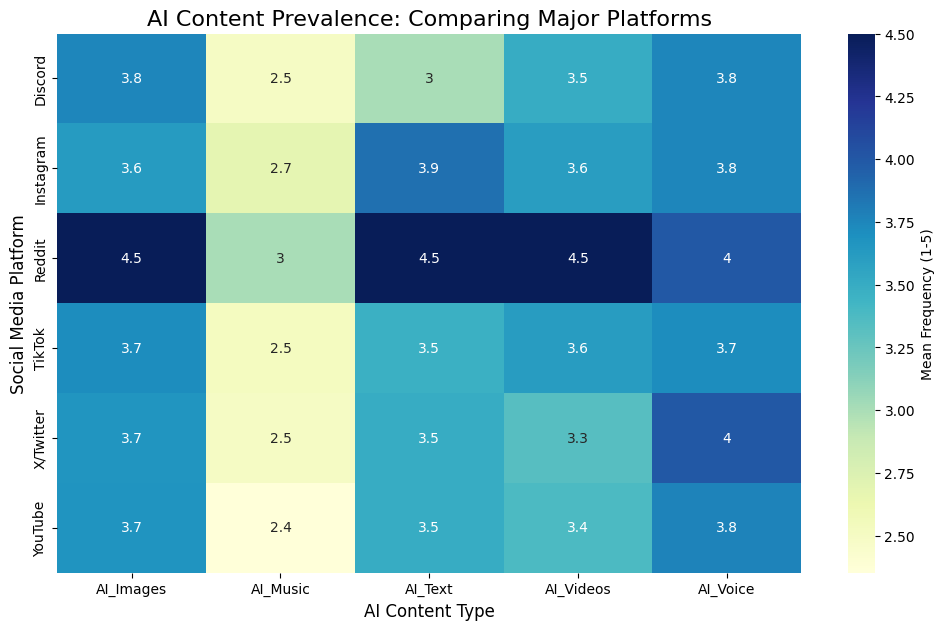

In [9]:
# the top 6 social media platform from survey
top_platforms = df['Platform'].value_counts().nlargest(6).index

joint = df[df['Platform'].isin(top_platforms)].pivot_table(
    values=['AI_Videos', 'AI_Images', 'AI_Text', 'AI_Music', 'AI_Voice'],
    index='Platform',
    aggfunc='mean'
)

plt.figure(figsize=(12, 7))
sns.heatmap(joint, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Mean Frequency (1-5)'})

plt.title('AI Content Prevalence: Comparing Major Platforms', size=16)
plt.xlabel('AI Content Type', size=12)
plt.ylabel('Social Media Platform', size=12)
plt.show()

**Explaination**: From the heatmap above, it shows that most of the student use Reddit and most likely see an AI image, AI text and AI video over other platform. On the otherhand, across every platform, it apears that the AI music is less likely to appear on the user feed.

### **2. User Sentiment by Platform**

In this section, we want to see the relationship between the social media platforms and the distribution of the user sentimental on the feed produced by AI.

Sentiment_5  Very Negative  Somewhat Negative    Neutral  Somewhat Positive  \
Platform                                                                      
Discord          25.000000          50.000000  25.000000           0.000000   
Instagram        32.467532          28.571429  33.766234           3.896104   
Reddit           50.000000          50.000000   0.000000           0.000000   
TikTok           42.857143          14.285714  33.333333           9.523810   
X/Twitter        66.666667          33.333333   0.000000           0.000000   
YouTube          32.352941          38.235294  23.529412           2.941176   

Sentiment_5  Very Positive  
Platform                    
Discord           0.000000  
Instagram         1.298701  
Reddit            0.000000  
TikTok            0.000000  
X/Twitter         0.000000  
YouTube           2.941176  


<Figure size 1200x800 with 0 Axes>

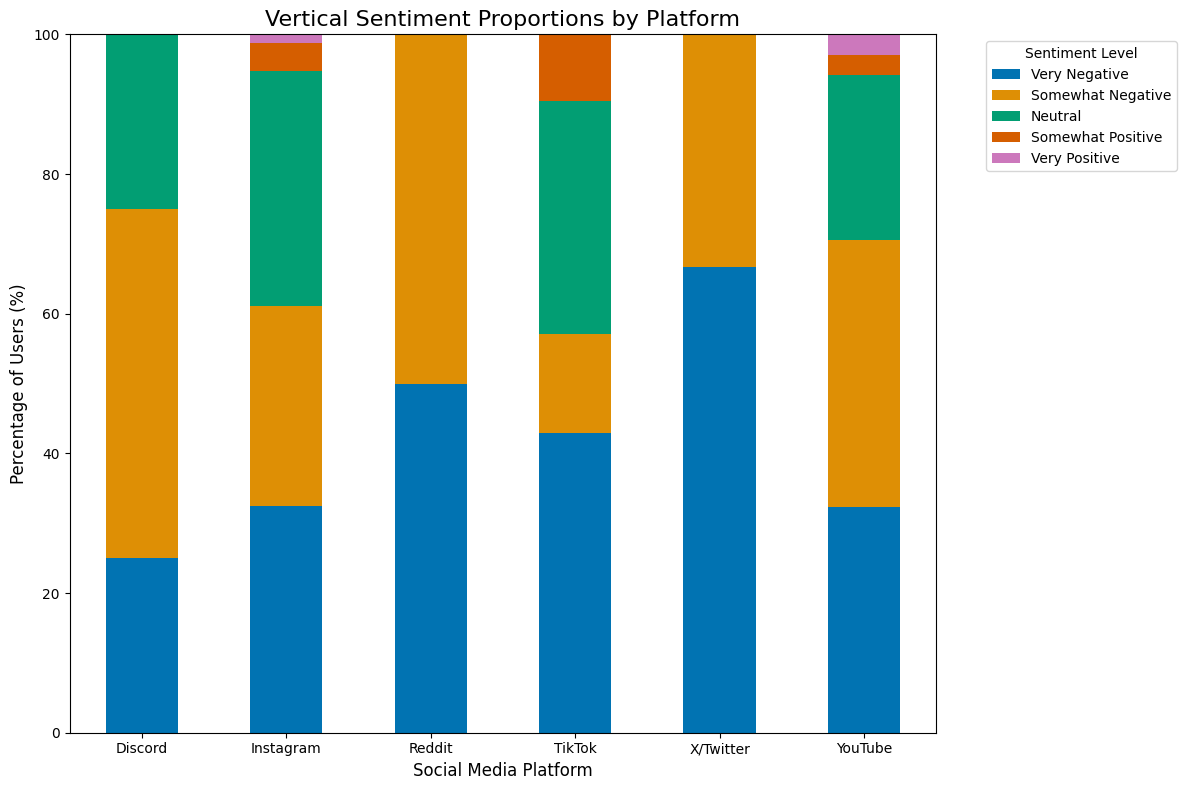

In [10]:

df_top = df[df['Platform'].isin(top_platforms)].copy()

# Define 5 bins
labels_5 = ['Very Negative', 'Somewhat Negative', 'Neutral', 'Somewhat Positive', 'Very Positive']
df_top['Sentiment_5'] = pd.cut(df_top['Sentiment'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=labels_5)

#create the frequency table
ct = pd.crosstab(df_top['Platform'], df_top['Sentiment_5'])

# Normalize to get percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print(ct_pct)

colors = sns.color_palette('colorblind', n_colors=ct.shape[1])
plt.figure(figsize=(12, 8))
ct_pct.plot(kind='bar', stacked=True, color=colors, figsize=(12, 8))
plt.title('Vertical Sentiment Proportions by Platform', size=16)
plt.ylabel('Percentage of Users (%)', size=12)
plt.xlabel('Social Media Platform', size=12)
plt.legend(title='Sentiment Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


**Explaination**: From the graph in this section, it illustrates that the  majority of the users have somewhat negative or negative toward the AI content on the social media. We can see that on X/Twitter, there are only somewhat negative or negative responce from the user. It also shows that there are a small percentage of user on Youtube has a positive review on AI content, however, it is still less than 6% of the youtube user.

### **3. Ethical Concerns and Verify Likelihood Towards AI-Generated Content**

In this section, we want to see how ethical concerns relates to the likelihood to verify AI-generated content and also see the distribution between the two.

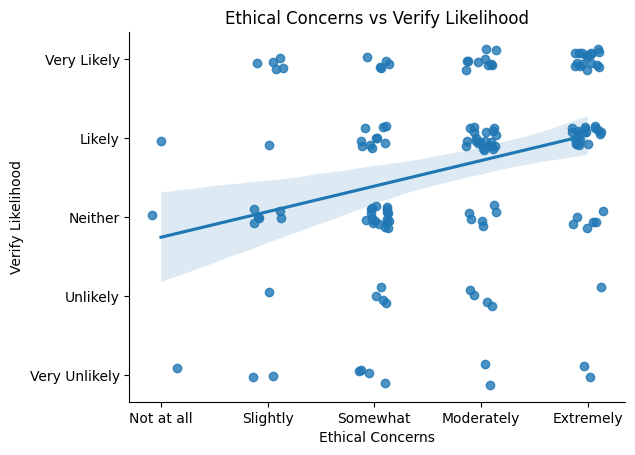

In [78]:
# added jitter to prevent points overlapping
sns.regplot(data = df, x = 'Ethical', y = 'Verify_Likelihood',
            x_jitter = 0.15, y_jitter = 0.15).set(
    title = 'Ethical Concerns vs Verify Likelihood',
    xlabel = 'Ethical Concerns',
    ylabel = 'Verify Likelihood'
)
# adjusted axes labels
x_labels = ['Not at all', 'Slightly', 'Somewhat', 'Moderately', 'Extremely']
y_labels = ['Very Unlikely', 'Unlikely', 'Neither', 'Likely', 'Very Likely']
plt.xticks(ticks=[1, 2, 3, 4, 5], labels = x_labels)
plt.yticks(ticks= [1, 2, 3, 4, 5], labels = y_labels)
sns.despine()

**Explaination**: Looking at scatterplot above, we see plenty of dense clusters towards the top right corner of the plot where users report being somewhat to extremely concerned about the ethics of AI usage and are neither likely nor unlikely to very likely to verify AI-generated content. Our line of best fit shows a positive slope, indicating that as the likelihood to verify tends to increase as ethical concerns increase.

### **4. Verify Likelihood Across Age Groups**

In this section, we wanted to compare the distribution of verify likelihood across age groups to see any common or different trends.

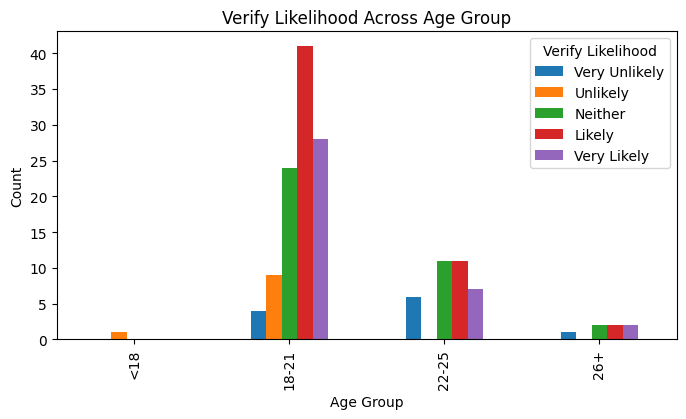

In [87]:
# df['Age'].value_counts() - checking age dist
# binning
bins = [11, 12, 22, 26, 32]
labels = ['<18', '18-21', '22-25', '26+']

df['Age_Group'] = pd.cut(df['Age'], bins = bins, labels = labels, right = False)
grouped = df.groupby(['Age_Group', 'Verify_Likelihood']).size().unstack(fill_value=0)

grouped.plot(kind = 'bar', figsize = (8, 4))
plt.title('Verify Likelihood Across Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')

# adjusted legend
plt.legend(title = 'Verify Likelihood',
           labels = ['Very Unlikely', 'Unlikely', 'Neither', 'Likely', 'Very Likely'])

**Explaination**: Based on the graph, we can see that all age groups except for <18 are mostly either unlikely nor likely to very likely to verify AI-generated content on their feed. There is a noticable peak in the 18-21 group where more than 40 people have reported that they are likely to verify AI-generated content.

### **5. Response counts by frequency and AI content type**

In this section, we will see where the people land in how frequently they see AI in each of these medias.

Frequency                 1   2   3   4   5
Media                                      
Images                    7   9  34  81  18
Influencers/Celebrities  27  48  42  25   7
Music                    19  56  52  18   4
Text/Captions            10  15  33  54  37
Videos                    8   7  51  67  16
Voice                     8  17  28  51  45
Media
Videos                     149
Images                     149
Influencers/Celebrities    149
Text/Captions              149
Music                      149
Voice                      149
dtype: int64


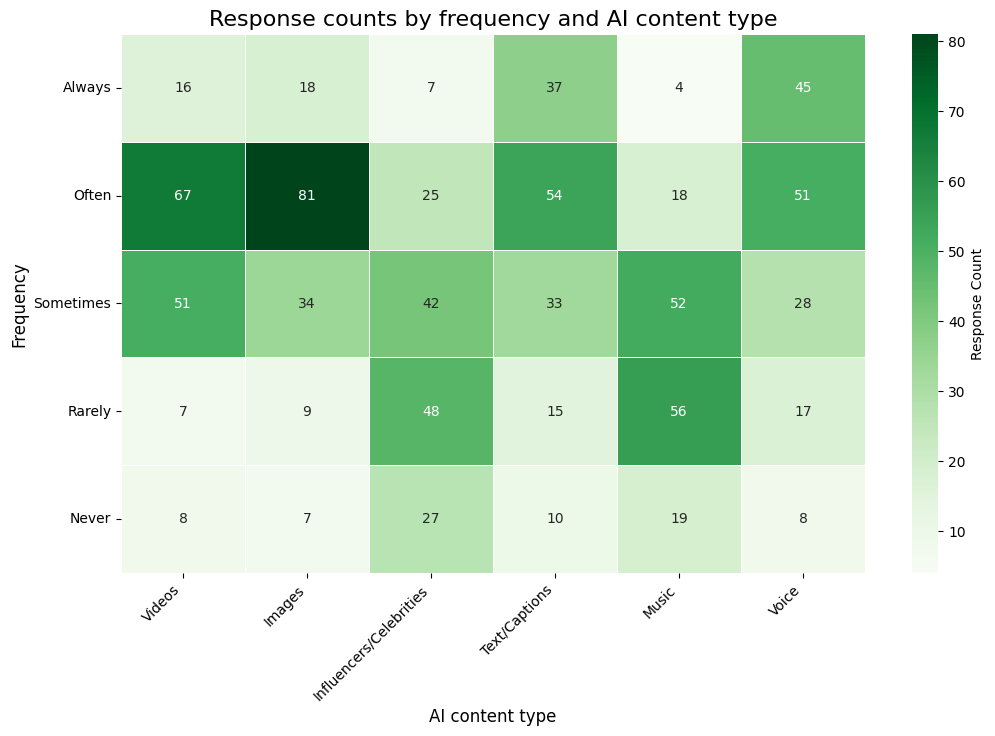

In [36]:
cols = ['AI_Videos', 'AI_Images', 'AI_Influencers', 'AI_Text', 'AI_Music', 'AI_Voice']

# melt turns data from wide format to long format
df_plot = df.melt(id_vars=['Platform'], value_vars=cols, var_name='Media', value_name='Frequency')
df_plot['Frequency'] = pd.to_numeric(df_plot['Frequency'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

df_plot['Media'] = df_plot['Media'].replace({
    'AI_Videos': 'Videos',
    'AI_Images': 'Images',
    'AI_Influencers': 'Influencers/Celebrities',
    'AI_Text': 'Text/Captions',
    'AI_Music': 'Music',
    'AI_Voice': 'Voice'
})

# compute raw counts of responses per Media x Frequency
# unstack created the pivot data
counts = df_plot.groupby(['Media', 'Frequency']).size().unstack(fill_value=0)
print(counts)

print(counts.sum(axis=1).reindex(['Videos', 'Images', 'Influencers/Celebrities', 'Text/Captions', 'Music', 'Voice']))

# transpose so the media are columns and freq are rows and get columns in correct order
heatmap_data = counts.T.reindex(columns=['Videos', 'Images', 'Influencers/Celebrities', 'Text/Captions', 'Music', 'Voice'], fill_value=0)
# we want Never at the bottom
heatmap_data = heatmap_data.iloc[::-1]

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, cmap='Greens', cbar_kws={'label': 'Response Count'}, linewidths=0.5)
plt.title('Response counts by frequency and AI content type', size=16)
plt.xlabel('AI content type', size=12)
plt.ylabel('Frequency', size=12)

# media types
plt.xticks(ticks=np.arange(len(heatmap_data.columns))+0.5, labels=heatmap_data.columns, rotation=45, ha='right')
# frequency labels
plt.yticks(ticks=np.arange(len(heatmap_data.index))+0.5, labels=['Always', 'Often', 'Sometimes', 'Rarely', 'Never'], rotation=0)

plt.show()

**Explaination**: This heatmap shows us out of our population (149), the number of people who saw different frequencies of AI on each media. The most common are AI are voice and images and the least common is music.

### **6. Mean rating of AI content verification per GPA bin**

In this section, we will see the mean rating of how often a person verifies AI content per GPA bin

bracket: 3.0 – 3.33, count: 29
bracket: 3.33 – 3.67, count: 41
bracket: 3.67 – 4.0, count: 47
bracket: 2.67 – 3.0, count: 13
bracket: Prefer not to say, count: 5
bracket: 2.33 – 2.67, count: 12
bracket: 2.0 – 2.33, count: 2


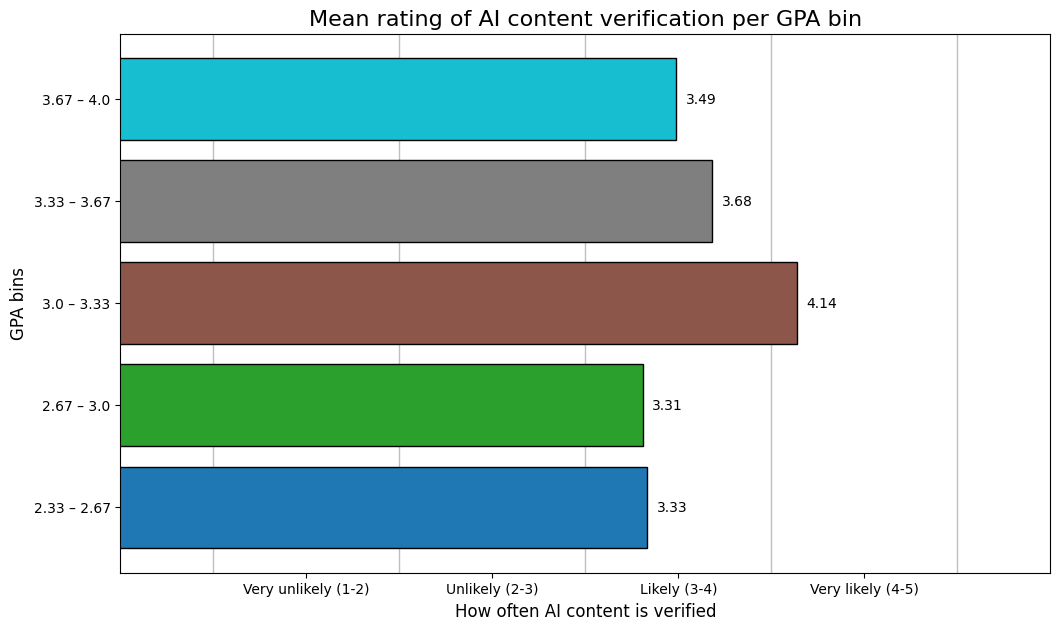

In [35]:
# print out the count for each brakcet - we drop some
for bracket in df['GPA'].unique():
    count = len(df[df['GPA'] == bracket])
    print(f"bracket: {bracket}, count: {count}")

df_filt = df[df['GPA'].isin(['2.33 – 2.67', '2.67 – 3.0', '3.0 – 3.33', '3.33 – 3.67', '3.67 – 4.0'])].copy()

# numeric conversion
df_filt['Verify_num'] = pd.to_numeric(
    df_filt['Verify_Likelihood'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

gpa_stats = df_filt.groupby('GPA')['Verify_num'].mean().dropna().reset_index()

# sort the GPA brackets (works without this)
gpa_stats['sort_by_this'] = gpa_stats['GPA'].str.extract(r'(\d+\.\d+)').astype(float)
gpa_stats = gpa_stats.sort_values('sort_by_this')

plt.figure(figsize=(12, 7))

# gray lines separating buckets
for x in [1, 2, 3, 4, 5]:
    plt.axvline(x=x, color='gray', alpha=0.5, linewidth=1, zorder=0)

bars = plt.barh(
    y=gpa_stats['GPA'],
    width=gpa_stats['Verify_num'],
    color=plt.cm.tab10(np.linspace(0, 1, len(gpa_stats))),
    edgecolor='black',
    zorder=1
)

# numeric text to the right of each bar
for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 0.05, bar.get_y() + bar.get_height()/2, f'{xval:.2f}', va='center')

plt.title('Mean rating of AI content verification per GPA bin', size=16)
plt.xlabel('How often AI content is verified', size=12)
plt.ylabel('GPA bins', size=12)

plt.xticks(ticks=[1.5, 2.5, 3.5, 4.5], labels=['Very unlikely (1-2)', 'Unlikely (2-3)', 'Likely (3-4)', 'Very likely (4-5)'])
plt.xlim(0.5, 5.5)
plt.show()

**Explaination**: This is an interesting set of results. The middle GPA group appears to be the most skeptical of AI content. Both the high and low GPA groups verify less, likely becuase they both are confident in their own knowledge to catch errors just by instinct.

### **7. Spider (Radar) Chart showing relation between social media platform and concerns for its ethical uses of AI-content**

In [ ]:
labels_5 = ['Not at All Concerned', 'Somewhat Not Concerned', 'Neutral', 'Somewhat Concerned', 'Highly Concerned']
df_top['Ethics_5'] = pd.cut(df_top['Ethical'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], labels=labels_5)
ethics_ct = pd.crosstab(df_top['Platform'], df_top['Ethics_5'])
ethics_ct_pct = ethics_ct.div(ethics_ct.sum(axis=1), axis=0) * 100

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["Discord"],
      theta=labels_5,
      fill='toself',
      name='Discord'
))

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["Instagram"],
      theta=labels_5,
      fill='toself',
      name='Instagram'
))

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["Reddit"],
      theta=labels_5,
      fill='toself',
      name='Reddit'
))

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["TikTok"],
      theta=labels_5,
      fill='toself',
      name='TikTok'
))

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["X/Twitter"],
      theta=labels_5,
      fill='toself',
      name='X/Twitter'
))

fig.add_trace(go.Scatterpolar(
      r=ethics_ct_pct.loc["YouTube"],
      theta=labels_5,
      fill='toself',
      name='YouTube'
))

fig.update_layout(
    polar = dict(
        radialaxis = dict(
            visible = True,
            range = [0, 70]
        )),
    showlegend = True
  )

fig.show()

**Explaination**:

https://plotly.com/python/radar-chart/

### **8. Parellel Coordinates Plot for each social media platform**

In [ ]:
filtered_df = df[df['Platform'].isin(top_platforms)]
filtered_df["Platform_ID"] = filtered_df['Platform'].astype("category").cat.codes
fig = px.parallel_coordinates(data_frame=filtered_df, color = "Platform_ID")
fig.show()


**Explaination**:

## **II. Formulating and Testing Hypotheses**
Clearly state at least 3 hypotheses or predictions based on your EDA.

For each hypothesis:
* Describe and justify the statistical test you are using.
* Perform the test using Python.
*: Analyze the results and draw a conclusion.

Use at least 2 different statistical tests across all hypotheses: at least one correlation analysis and a chi-squared test.

### **Hypothesis 1**: There is a relationship between ethical concerns and the likelihood to verify AI-generated content.


**Test**: Kendall's Tau Correlation Test


In [14]:
# import scipy.stats as stats for kendalltau function
correlation, pvalue = stats.kendalltau(df['Ethical'], df['Verify_Likelihood'])
print(f'Kendall Tau: {correlation}')
print(f'P-value: {pvalue}')

Kendall Tau: 0.27572773460548355
P-value: 6.321280871115027e-05


**Analyze and Conclusion**: We used Kendall's Tau Correlation Test to see if there was a relationship between ethical concerns and verify likelihood because there are two categorical (ordinal) variables, and we are pulling data from a small dataset. Our tau correlation coefficient of about 0.28 shows a weak positive correlation between ethical concerns and verify likelihood, meaning that those who are more concerned with the ethical usage of AI tend to be more likely to verify if content on their social media feed is AI-generated. Our p-value of less than 0.05 shows that the relationship is statistically signficiant and is unlikely due to random chance. Hence, we reject the null hypothesis.



### **Hypothesis 2**: There is a relationship between a student's main social media platform and their sentiment toward AI-generated content.


**Test**: Chi-Squared Test of Independence

In [86]:
# Combine "discord" and "Discord" from Platforms
chi_squared_table = df.copy()
chi_squared_table["Platform"] = chi_squared_table["Platform"].replace({
    "discord": "Discord"
})

contingency_table = pd.crosstab(chi_squared_table["Platform"], chi_squared_table["Sentiment"])
print(contingency_table)

# Run the Chi-Squared Test
# Code gathered from here: https://pythonfordatascienceorg.wordpress.com/chi-square-python/#custom-function
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi2 value= {chi2}{"\n"}p-value= {p}{"\n"}Degrees of freedom= {dof}{"\n"}")

Sentiment  1.0  2.0  3.0  4.0  5.0
Platform                          
BiliBili     0    0    0    1    0
Discord      1    2    2    0    0
Facebook     1    1    0    0    0
Instagram   25   22   26    3    1
Reddit       1    1    0    0    0
Telegram     0    1    0    0    0
TikTok       9    3    7    2    0
X/Twitter    4    2    0    0    0
YouTube     11   13    8    1    1
Chi2 value= 36.16930270827183
p-value= 0.2800484277646858
Degrees of freedom= 32



**Analyze and Conclusion**: We used the Chi-Squared Test of Independence to see if there was a relationship between a student's main social media platform and their sentiment towards AI-generared content. This test was used because both variables are catagorical. The Chi-Squared value is about 36.169 which shows the difference between the observed counts and the counts we would expect if the two variables, Platform and Sentiment, were independent. Because the p-value of about 0.280 is greater than 0.05, the result is not statistically significant. We fail to reject the null hypothesis and do not have enough evidence to conclude that a student's main social media platform is related to their sentiment toward AI-generated content.



### **Hypothesis 3**:


**Test**:

**Analyze and Conclusion**:



## Conclusion


## Group Contrubution


* Andrew Maciborski: Graphs 5 and 6
* Vincent Chau: Graphs 7 and 8
* Lyda Taing: Cleaning data, Graphs 1 and 2
* Christie Wong: Graphs 3 and 4, Hypothesis 1
* Daniel Remedios: Hypotheses 2 and 3



In [ ]:
#submisson
#!sudo apt-get update
#!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
#!pip install pypandoc
#!jupyter nbconvert --log-level DEBUG --to pdf "<file name>.ipynb"